In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


# Data Preprocessing:

In [2]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
#check the shape
df.shape

(3999, 12)

In [4]:
#display the information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
#display the columns
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [6]:
#statistical summary
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
#checking the missing values
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [9]:
#checking the duplicated values
df.duplicated().sum()

np.int64(0)

In [10]:
#checking the unique values
for column in df.columns:
    print(column, ":", df[column].nunique())

ID# : 3999
Balance : 3904
Qual_miles : 164
cc1_miles : 5
cc2_miles : 3
cc3_miles : 5
Bonus_miles : 2734
Bonus_trans : 57
Flight_miles_12mo : 343
Flight_trans_12 : 35
Days_since_enroll : 2820
Award? : 2


In [11]:
#Separate ID and Clustering Features
features = [
    'Balance',
    'Qual_miles',
    'cc1_miles',
    'cc2_miles',
    'cc3_miles',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Days_since_enroll'
]

X = df[features]

print(X.shape)

(3999, 10)


In [14]:
#checking the outliers
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_counts = ((X < lower_bound) | (X > upper_bound)).sum()

print(outlier_counts)
outlier_summary = pd.DataFrame({
    "Feature": features,
    "Outlier_Count": outlier_counts.values
})

outlier_summary

Balance              266
Qual_miles           226
cc1_miles              0
cc2_miles             43
cc3_miles             18
Bonus_miles          280
Bonus_trans           63
Flight_miles_12mo    569
Flight_trans_12      565
Days_since_enroll      0
dtype: int64


,Feature,Outlier_Count
0,Balance,266
1,Qual_miles,226
2,cc1_miles,0
3,cc2_miles,43
4,cc3_miles,18
5,Bonus_miles,280
6,Bonus_trans,63
7,Flight_miles_12mo,569
8,Flight_trans_12,565
9,Days_since_enroll,0


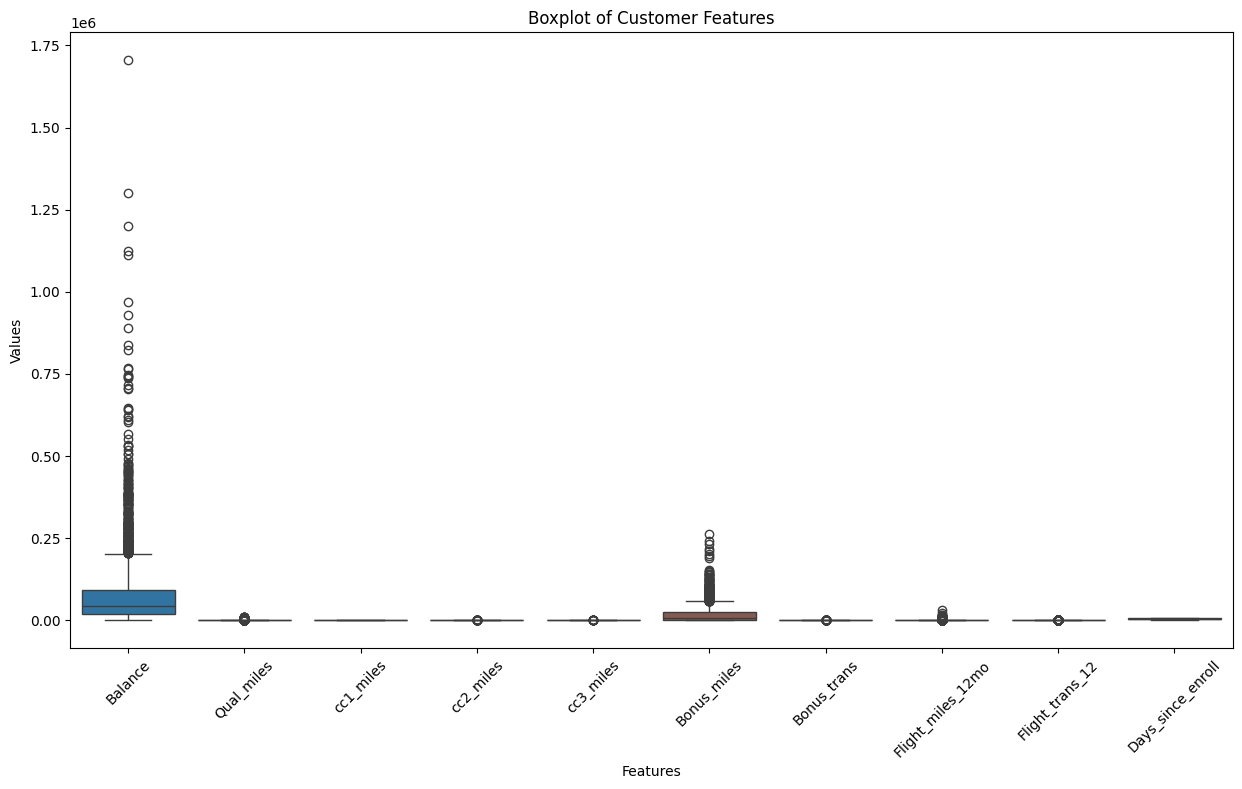

In [15]:
#visualize the outliers using the boxplot
plt.figure(figsize=(15, 8))

sns.boxplot(data=X)

plt.xticks(rotation=45)
plt.title("Boxplot of Customer Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [16]:
#removing the outliers
outlier_mask = (
    (X < lower_bound) |
    (X > upper_bound)
).any(axis=1)

df_clean = df[~outlier_mask].copy()

print("Original dataset shape:", df.shape)
print("Dataset shape after removing outliers:", df_clean.shape)

Original dataset shape: (3999, 12)
Dataset shape after removing outliers: (2875, 12)


In [18]:
df_clean.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
5,6,16420,0,1,1,1,0,0,0,0,6942,0


In [19]:
#checking the null values in df_clean dataframe
df_clean.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [25]:
#checking the duplicated values in df_clean data
print("duplicated:",df_clean.duplicated().sum())

#Creating Clean Clustering Dataset
X_clean = df_clean[features]

print(X_clean.shape)

duplicated: 0
(2875, 10)


In [26]:
#feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features,
    index=X_clean.index
)

X_scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206
5,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312


In [27]:
#verifying the standard scaler
print("Mean of each feature:")
print(X_scaled_df.mean())

print("\nStandard deviation of each feature:")
print(X_scaled_df.std())

Mean of each feature:
Balance             -7.908650e-17
Qual_miles           0.000000e+00
cc1_miles           -7.908650e-17
cc2_miles            0.000000e+00
cc3_miles            0.000000e+00
Bonus_miles         -5.931487e-17
Bonus_trans          8.402940e-17
Flight_miles_12mo    1.482872e-17
Flight_trans_12      2.965744e-17
Days_since_enroll   -7.908650e-17
dtype: float64

Standard deviation of each feature:
Balance              1.000174
Qual_miles           0.000000
cc1_miles            1.000174
cc2_miles            0.000000
cc3_miles            0.000000
Bonus_miles          1.000174
Bonus_trans          1.000174
Flight_miles_12mo    1.000174
Flight_trans_12      1.000174
Days_since_enroll    1.000174
dtype: float64


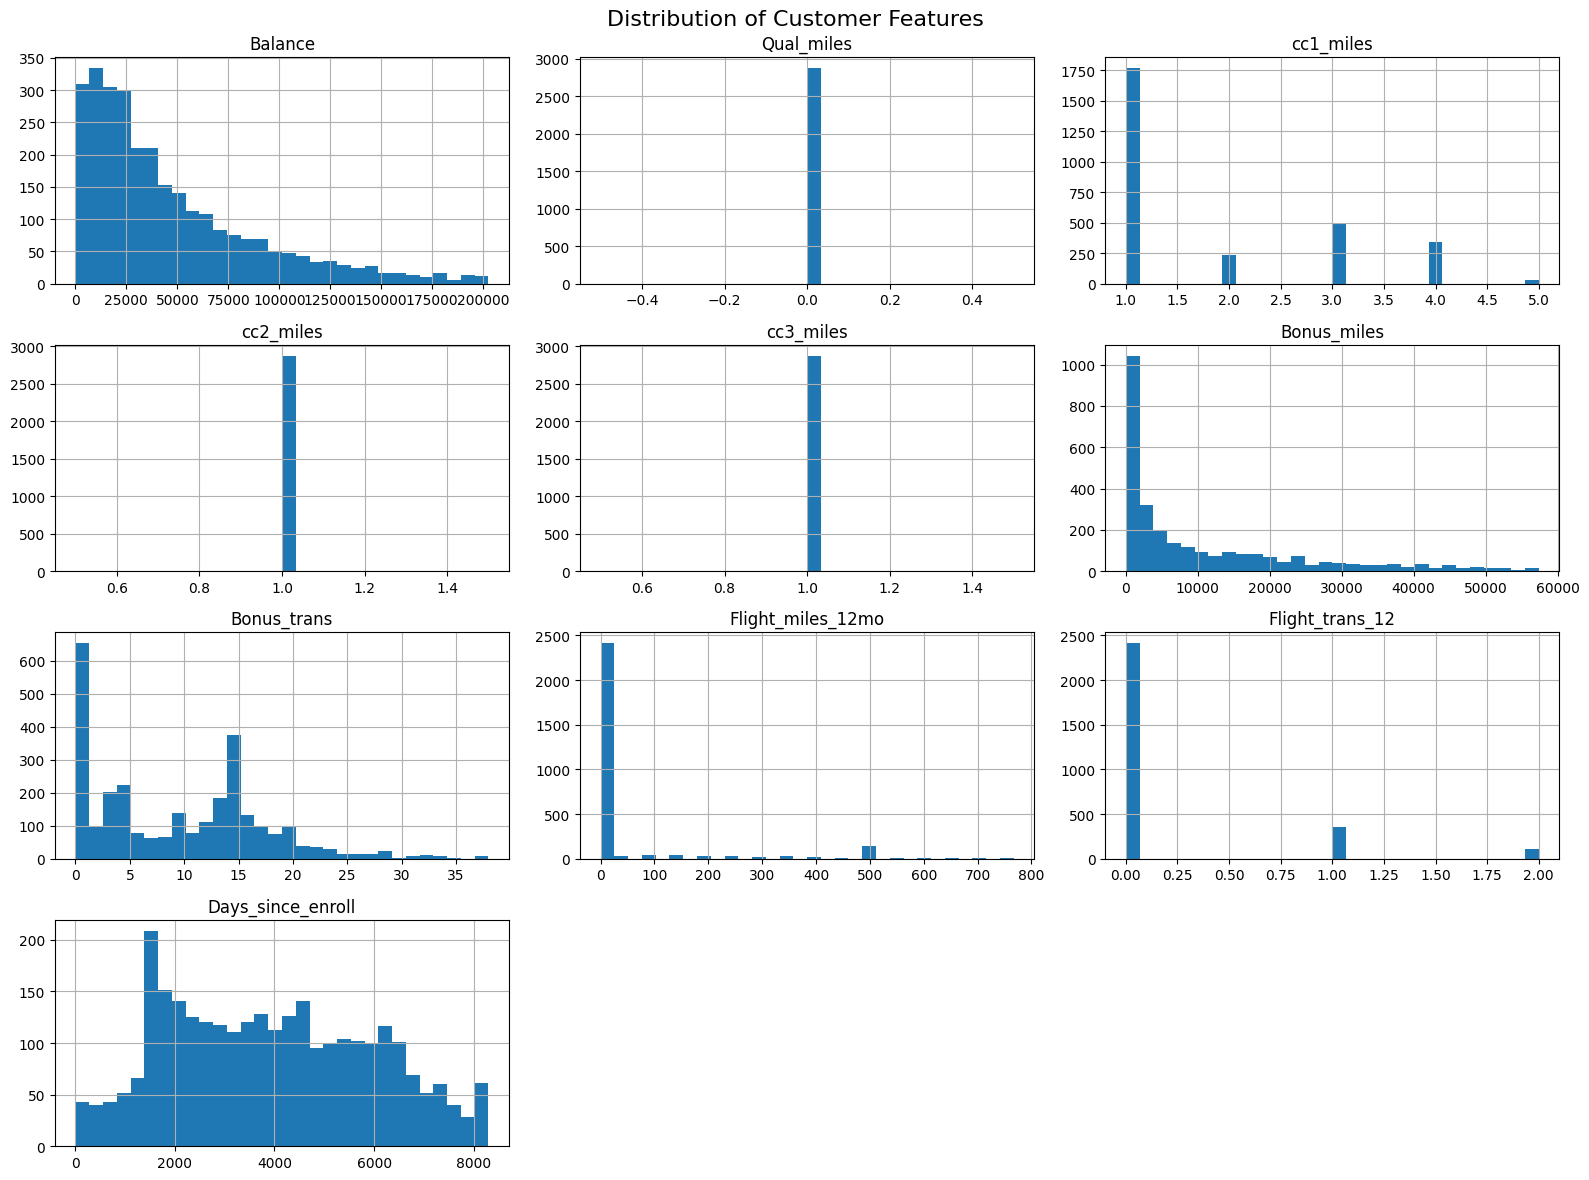

In [28]:
#histogram
X_clean.hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Customer Features", fontsize=16)
plt.tight_layout()
plt.show()

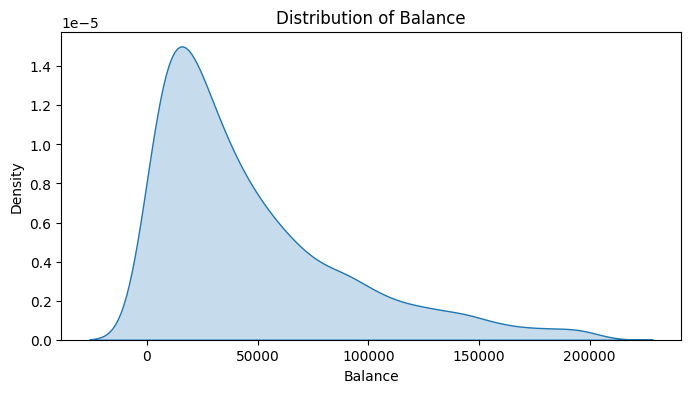

C:\Users\BALAJI\AppData\Local\Temp\ipykernel_45892\1755599847.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


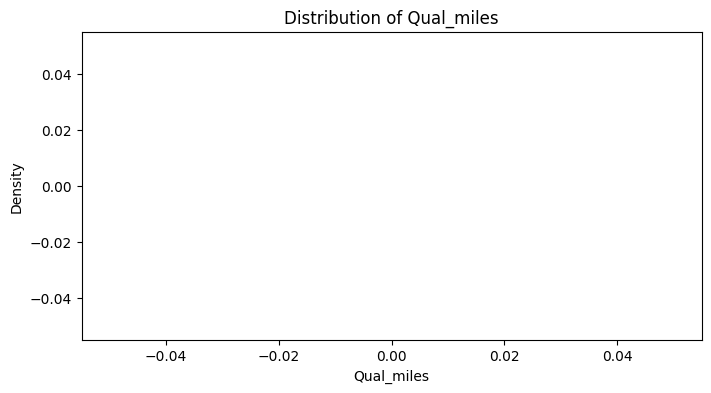

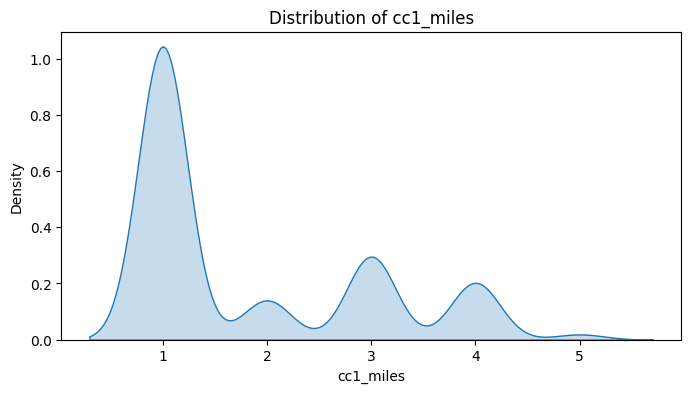

C:\Users\BALAJI\AppData\Local\Temp\ipykernel_45892\1755599847.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


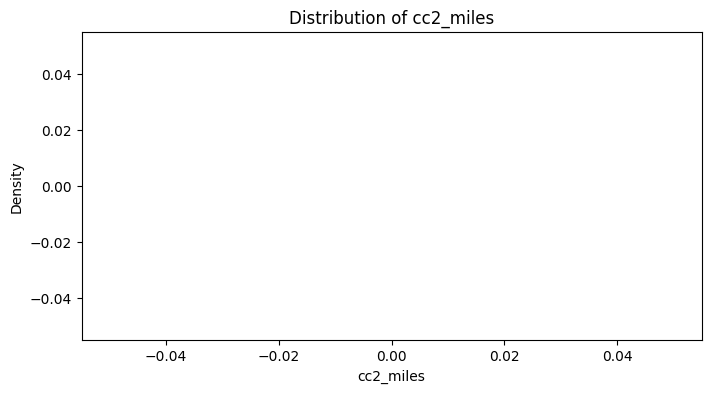

C:\Users\BALAJI\AppData\Local\Temp\ipykernel_45892\1755599847.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


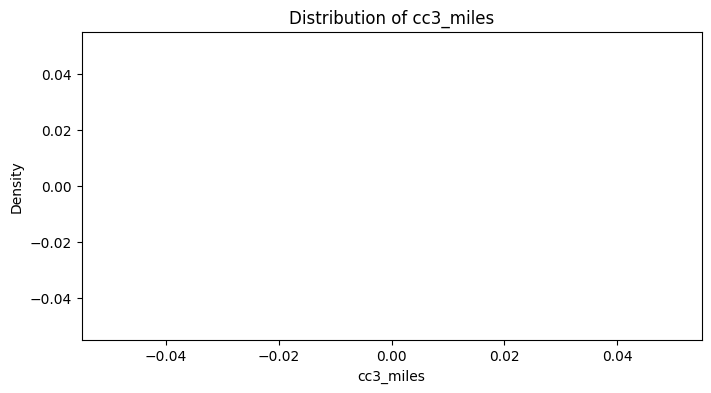

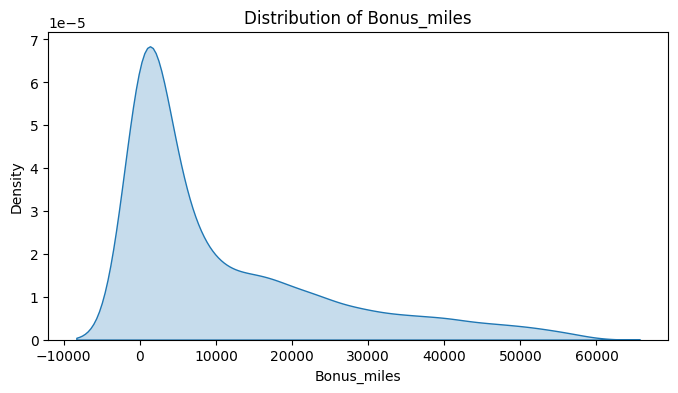

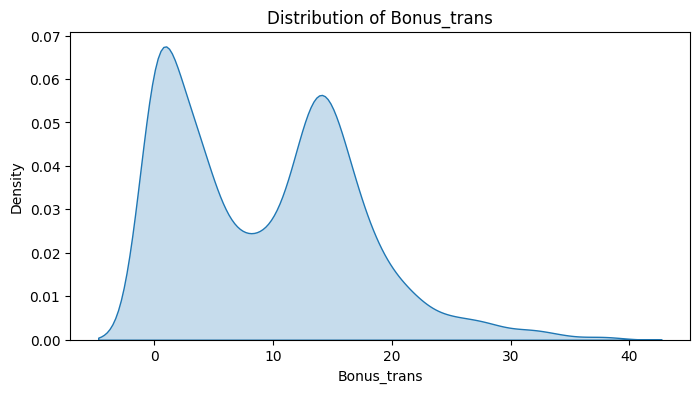

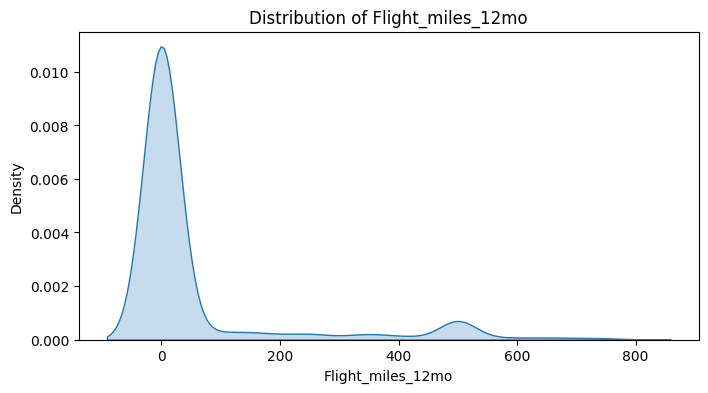

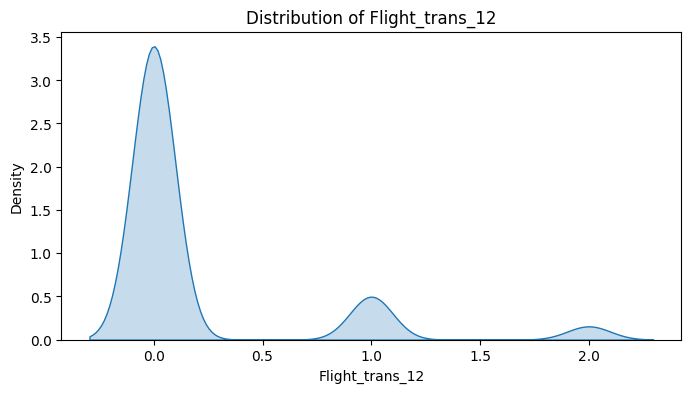

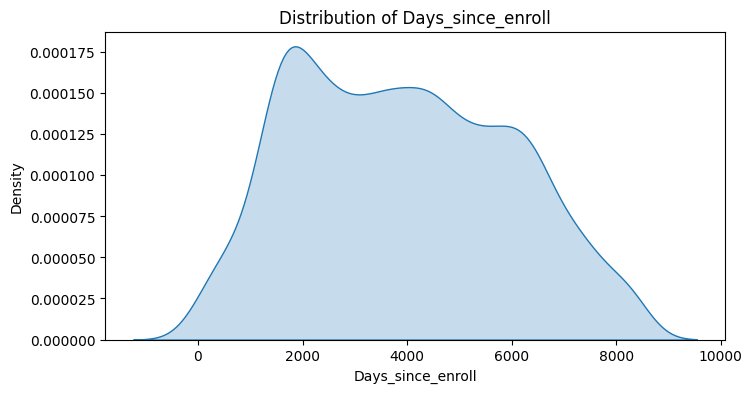

In [29]:
for column in features:
    plt.figure(figsize=(8, 4))
    
    sns.kdeplot(
        data=X_clean,
        x=column,
        fill=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.show()

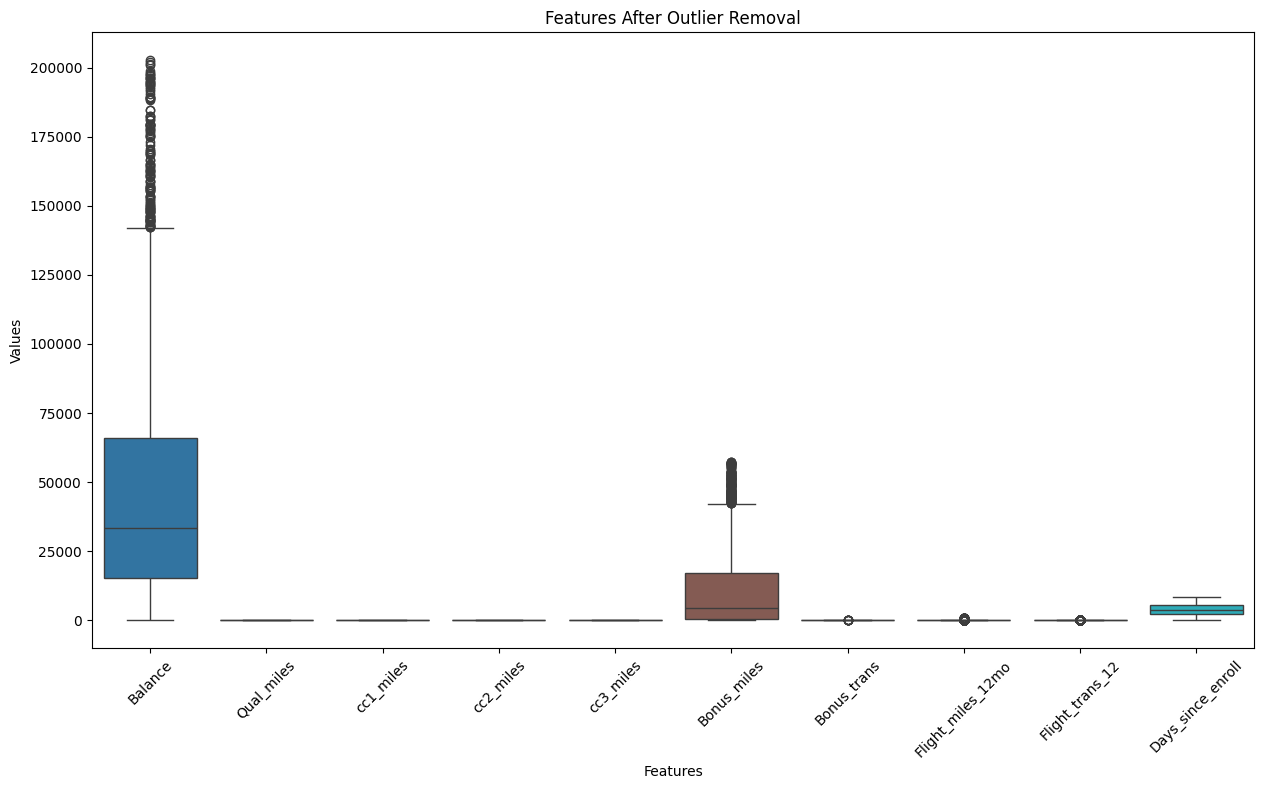

In [30]:
#boxplot
plt.figure(figsize=(15, 8))

sns.boxplot(data=X_clean)

plt.xticks(rotation=45)
plt.title("Features After Outlier Removal")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [32]:
#correlation analysis
correlation_matrix = X_clean.corr()

correlation_matrix.round(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Balance,1.00,NaN,0.46,NaN,NaN,0.46,0.36,0.16,0.15,0.24
Qual_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc1_miles,0.46,NaN,1.00,NaN,NaN,0.91,0.63,0.08,0.07,0.18
cc2_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc3_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bonus_miles,0.46,NaN,0.91,NaN,NaN,1.00,0.62,0.11,0.09,0.15
Bonus_trans,0.36,NaN,0.63,NaN,NaN,0.62,1.00,0.10,0.11,0.13
Flight_miles_12mo,0.16,NaN,0.08,NaN,NaN,0.11,0.10,1.00,0.86,0.03
Flight_trans_12,0.15,NaN,0.07,NaN,NaN,0.09,0.11,0.86,1.00,0.03
Days_since_enroll,0.24,NaN,0.18,NaN,NaN,0.15,0.13,0.03,0.03,1.00


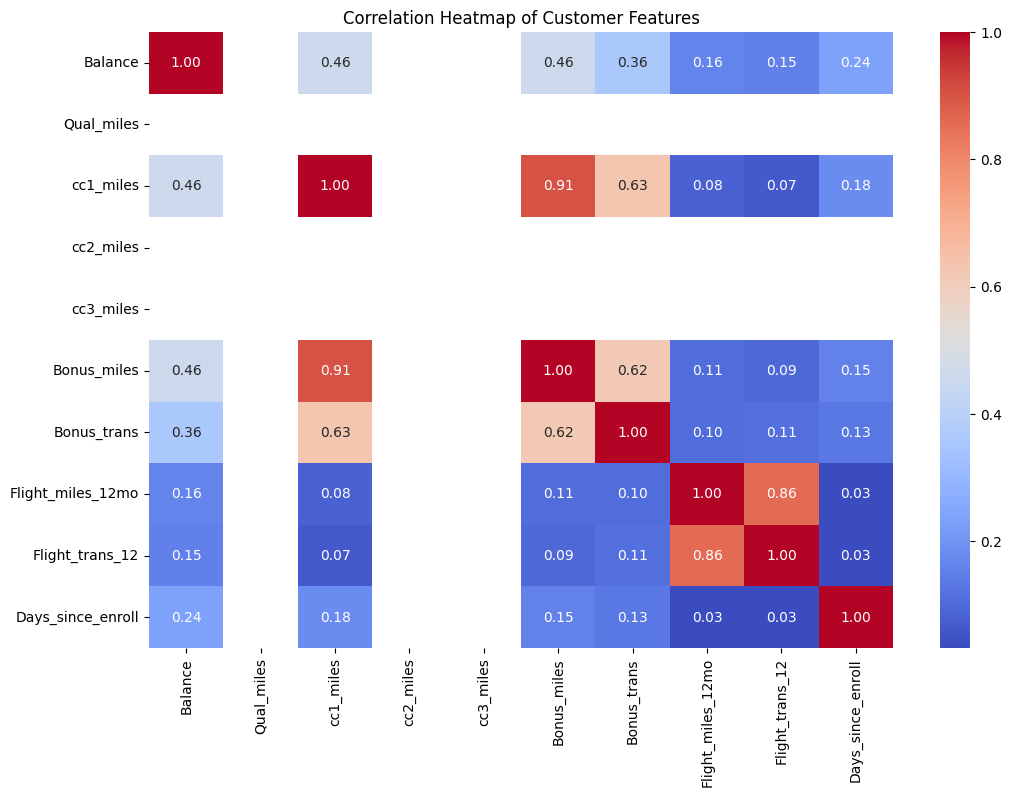

In [33]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Customer Features")

plt.show()

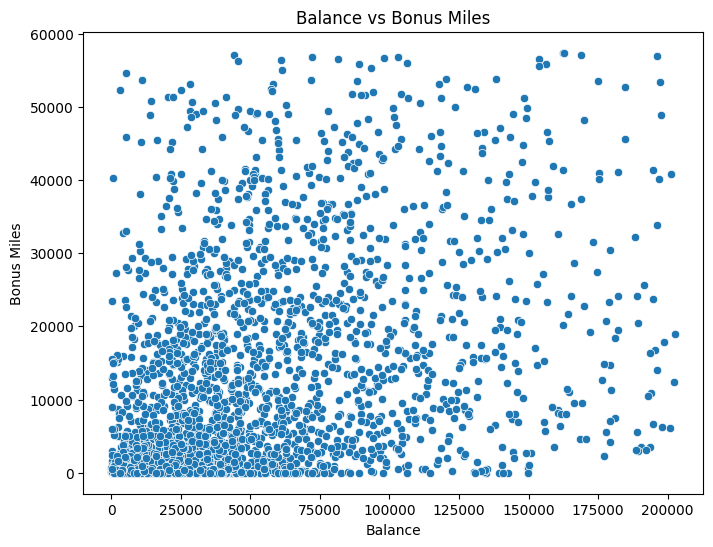

In [34]:
#scatterplot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=X_clean,
    x="Balance",
    y="Bonus_miles"
)

plt.title("Balance vs Bonus Miles")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")

plt.show()

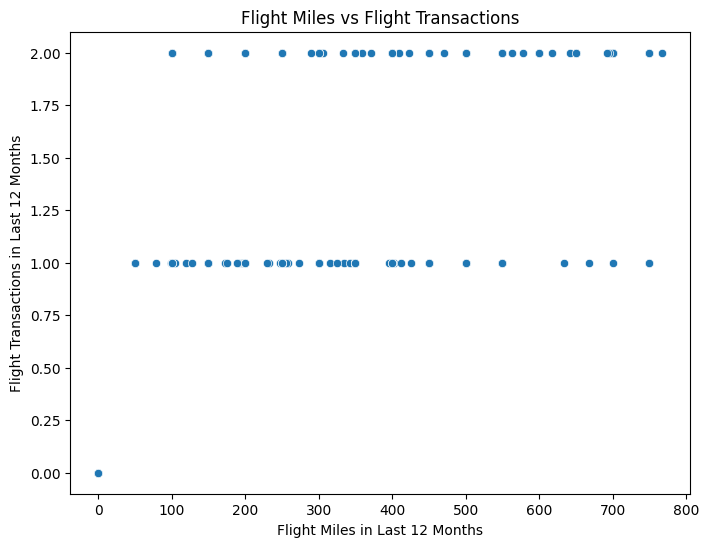

In [35]:
#Scatter Plot — Flight Miles vs Flight Transactions
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=X_clean,
    x="Flight_miles_12mo",
    y="Flight_trans_12"
)

plt.title("Flight Miles vs Flight Transactions")
plt.xlabel("Flight Miles in Last 12 Months")
plt.ylabel("Flight Transactions in Last 12 Months")

plt.show()

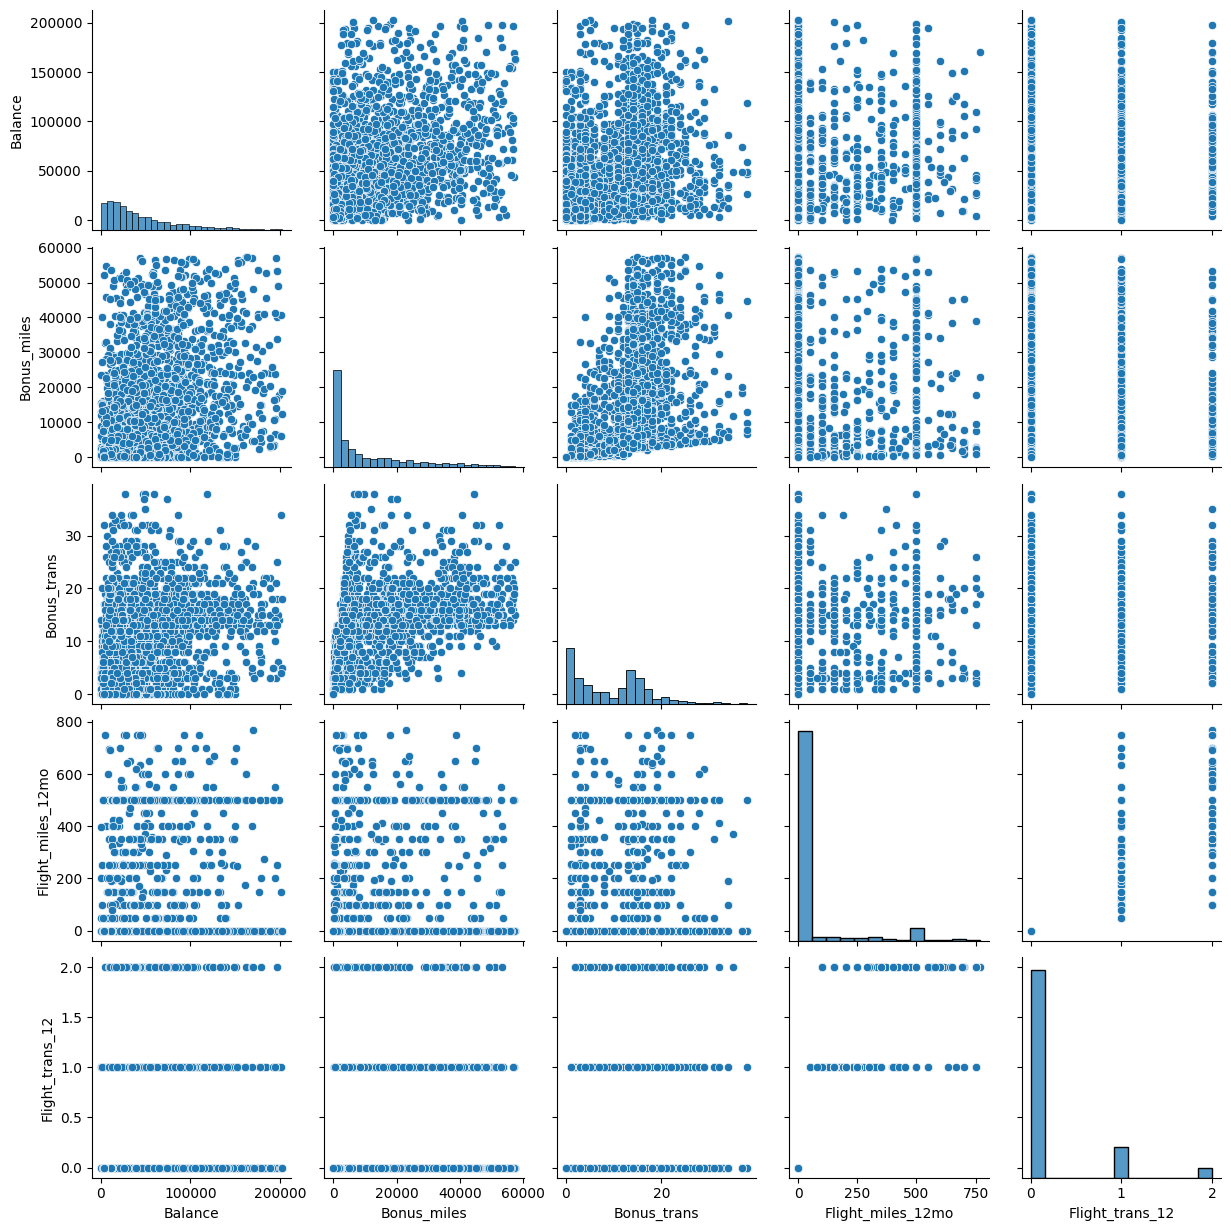

In [36]:
#pairplot
selected_features = [
    "Balance",
    "Bonus_miles",
    "Bonus_trans",
    "Flight_miles_12mo",
    "Flight_trans_12"
]

sns.pairplot(
    X_clean[selected_features]
)

plt.show()

In [37]:
#Visualize the Scaled Data Using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()


,PC1,PC2
0,-1.324561,-0.187209
1,-1.349013,-0.198874
2,-0.877511,-0.292041
3,-1.438053,-0.184058
4,-1.500789,-0.162252


Explained variance ratio:
[0.41535705 0.25506118]
Total variance explained: 0.6704182391649207


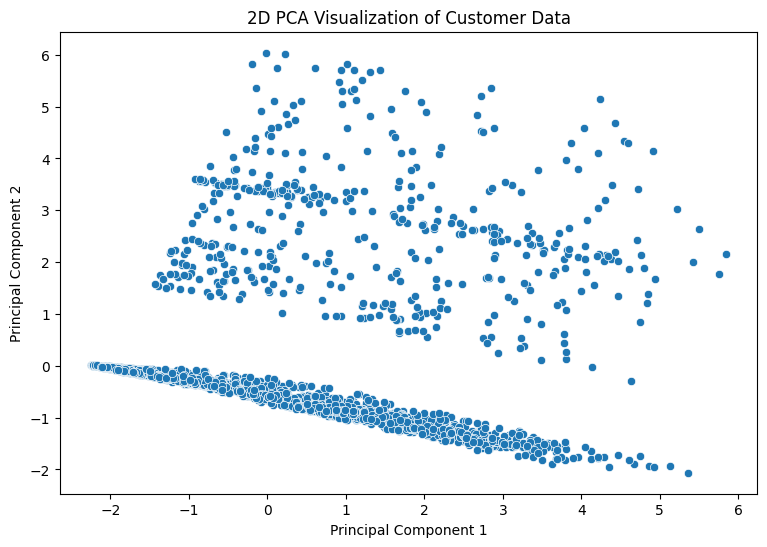

In [39]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)


plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2"
)

plt.title("2D PCA Visualization of Customer Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [40]:
#final preprocessed data
print("Final clustering dataset:")
print(X_scaled_df.shape)

Final clustering dataset:
(2875, 10)


# Implementing Clustering Algorithms:

In [42]:
#kMeans clustering using the elbow method
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

In [43]:
#analysing using different k-values
silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)
    
    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.3491
K = 3, Silhouette Score = 0.3776
K = 4, Silhouette Score = 0.2717
K = 5, Silhouette Score = 0.2789
K = 6, Silhouette Score = 0.2706
K = 7, Silhouette Score = 0.2851
K = 8, Silhouette Score = 0.2822
K = 9, Silhouette Score = 0.2809
K = 10, Silhouette Score = 0.2837


In [45]:
#final k-means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)
df_kmeans = df_clean.copy()

df_kmeans["KMeans_Cluster"] = kmeans_labels

df_kmeans.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
5,6,16420,0,1,1,1,0,0,0,0,6942,0,0


KMeans_Cluster
0    1662
1     364
2     849
Name: count, dtype: int64


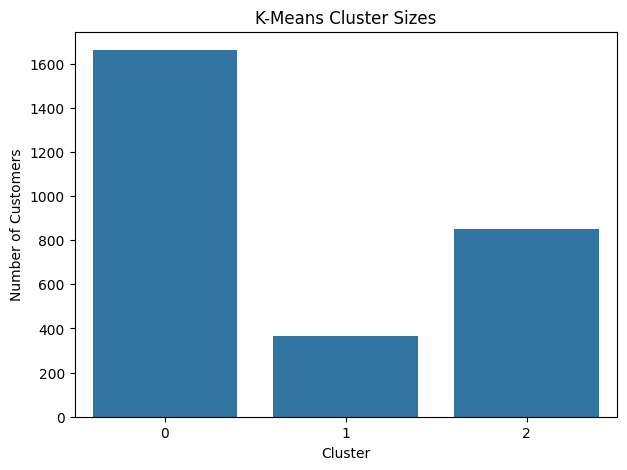

In [47]:
#displaying the cluster size
cluster_counts = df_kmeans["KMeans_Cluster"].value_counts().sort_index()

print(cluster_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("K-Means Cluster Sizes")

plt.show()

In [48]:
#kmeans silhouette score
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)

K-Means Silhouette Score: 0.3776


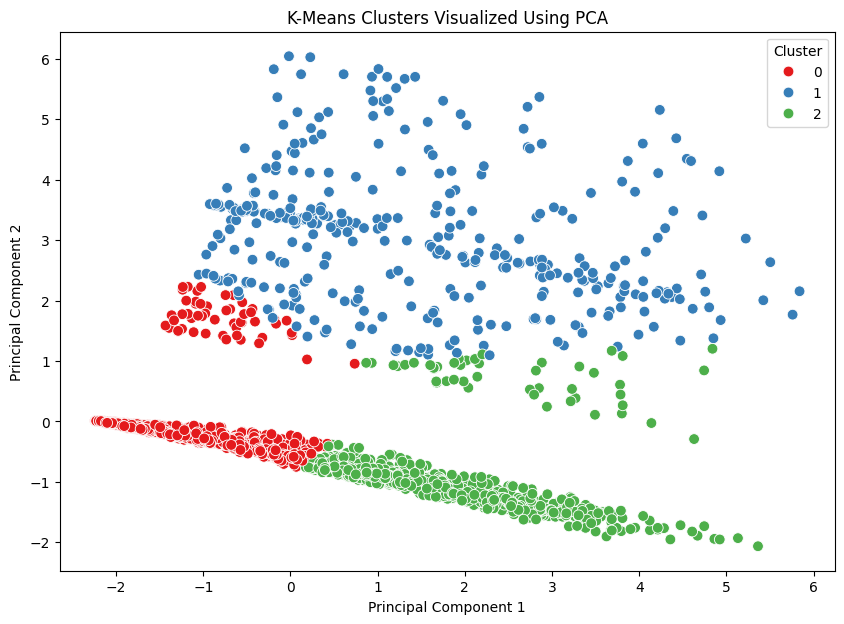

In [50]:
#Visualize K-Means Clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_visual = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_visual["Cluster"] = kmeans_labels

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_visual,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60
)

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [52]:
#DBSCAN Clustering

DBSCAN(
    eps=0.5,
    min_samples=5
)
#First DBSCAN Model
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)
print(np.unique(dbscan_labels))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]


In [53]:
#Count DBSCAN Clusters
unique_labels = set(dbscan_labels)

n_clusters = len(
    unique_labels - {-1}
)

n_noise = np.sum(
    dbscan_labels == -1
)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 14
Number of noise points: 938


In [54]:
#analysing the dbscan parameters
unique_labels = set(dbscan_labels)

n_clusters = len(
    unique_labels - {-1}
)

n_noise = np.sum(
    dbscan_labels == -1
)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 14
Number of noise points: 938


In [55]:
#Evaluate DBSCAN Using Silhouette Score
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.5]

for eps in eps_values:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(
        set(labels) - {-1}
    )
    
    n_noise = np.sum(
        labels == -1
    )
    
    print(
        f"eps={eps}, "
        f"clusters={n_clusters}, "
        f"noise points={n_noise}"
    )

eps=0.3, clusters=15, noise points=1656
eps=0.4, clusters=21, noise points=1268
eps=0.5, clusters=14, noise points=938
eps=0.6, clusters=11, noise points=693
eps=0.7, clusters=11, noise points=552
eps=0.8, clusters=13, noise points=455
eps=1.0, clusters=8, noise points=244
eps=1.2, clusters=6, noise points=151
eps=1.5, clusters=4, noise points=56


In [56]:
#test different parameters
eps = 1.5

min_samples_values = [3, 5, 7, 10, 15]

for min_samples in min_samples_values:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(
        set(labels) - {-1}
    )
    
    n_noise = np.sum(
        labels == -1
    )
    
    non_noise = labels != -1
    
    if n_clusters >= 2:
        score = silhouette_score(
            X_scaled[non_noise],
            labels[non_noise]
        )
    else:
        score = np.nan
    
    print(
        f"min_samples={min_samples}, "
        f"clusters={n_clusters}, "
        f"noise={n_noise}, "
        f"silhouette={score:.4f}"
    )

min_samples=3, clusters=4, noise=45, silhouette=0.3243
min_samples=5, clusters=4, noise=56, silhouette=0.3233
min_samples=7, clusters=5, noise=79, silhouette=0.3207
min_samples=10, clusters=3, noise=114, silhouette=0.3345
min_samples=15, clusters=3, noise=138, silhouette=0.3290


In [58]:
#final dbscan model
dbscan_final = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels_final = dbscan_final.fit_predict(X_scaled)
df_dbscan = df_clean.copy()

df_dbscan["DBSCAN_Cluster"] = dbscan_labels_final

df_dbscan.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
5,6,16420,0,1,1,1,0,0,0,0,6942,0,0


In [59]:
#final dbscan statistics
dbscan_clusters = len(
    set(dbscan_labels_final) - {-1}
)

dbscan_noise = np.sum(
    dbscan_labels_final == -1
)

print("Number of DBSCAN clusters:", dbscan_clusters)
print("Number of noise points:", dbscan_noise)

Number of DBSCAN clusters: 4
Number of noise points: 56


In [60]:
#final dbscan silhoutte score
non_noise = dbscan_labels_final != -1

dbscan_silhouette = silhouette_score(
    X_scaled[non_noise],
    dbscan_labels_final[non_noise]
)

print(
    "DBSCAN Silhouette Score:",
    round(dbscan_silhouette, 4)
)

DBSCAN Silhouette Score: 0.3233


--------------------------------------------------


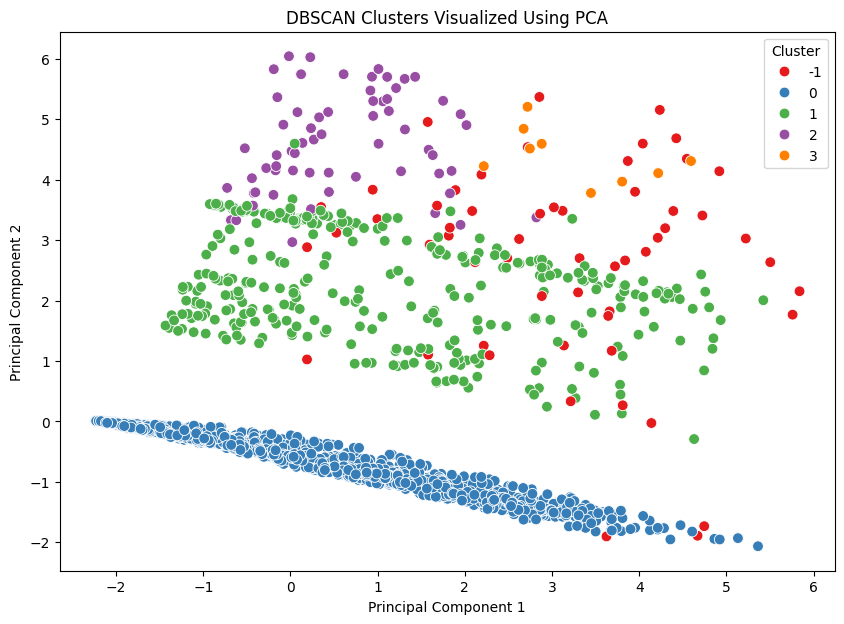

In [61]:
#visualize dbscan clusters
pca_dbscan = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_dbscan["Cluster"] = dbscan_labels_final

print("-"*50)
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_dbscan,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60
)

plt.title("DBSCAN Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [62]:
#comparing the kmeans and DBScan
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "DBSCAN"
    ],
    
    "Number of Clusters": [
        len(set(kmeans_labels)),
        dbscan_clusters
    ],
    
    "Noise Points": [
        0,
        dbscan_noise
    ],
    
    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette
    ]
})

print(comparison.round(4))

  Algorithm  Number of Clusters  Noise Points  Silhouette Score
0   K-Means                   3             0            0.3776
1    DBSCAN                   4            56            0.3233


# Cluster Analysis and Interpretation

In [64]:
#K-Means Cluster Analysis
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)
df_kmeans = df_clean.copy()
df_kmeans["KMeans_Cluster"] = kmeans_labels

print("Check Number of Customers in Each Cluster")
cluster_counts = (
    df_kmeans["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Check Number of Customers in Each Cluster
KMeans_Cluster
0    1662
1     364
2     849
Name: count, dtype: int64


In [65]:
#Calculate Average Characteristics of Each Cluster
kmeans_summary = df_kmeans.groupby(
    "KMeans_Cluster"
)[features].mean()

print(kmeans_summary.round(2))


                 Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                          
0               28238.91         0.0       1.08        1.0        1.0   
1               64603.76         0.0       2.03        1.0        1.0   
2               75638.42         0.0       3.21        1.0        1.0   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                 
0                   2887.95         5.40               3.47             0.03   
1                  14108.71        11.65             420.76             1.30   
2                  25116.99        16.21               6.12             0.05   

                Days_since_enroll  
KMeans_Cluster                     
0                         3577.83  
1                         4096.76  
2                         4537.61  


In [66]:
kmeans_summary.round(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
KMeans_Cluster,,,,,,,,,,
0,28238.91,0.0,1.08,1.0,1.0,2887.95,5.40,3.47,0.03,3577.83
1,64603.76,0.0,2.03,1.0,1.0,14108.71,11.65,420.76,1.30,4096.76
2,75638.42,0.0,3.21,1.0,1.0,25116.99,16.21,6.12,0.05,4537.61


#### Interpretation of K-Means Clusters

Cluster 0 — Lower-balance / Lower-engagement customers

    Lowest average balance: 28,238.9
    Lowest cc1_miles: 1.1
    Lowest bonus miles: 2,888
    Lowest bonus transactions: 5.4
    Relatively low recent flight activity.
    Largest segment with 1,662 customer

Cluster 1 — Moderate-engagement customers

    Average balance: 64,603.8
    cc1_miles: 2.0
    Bonus miles: 14,108.7
    Bonus transactions: 11.7
    Highest Flight_miles_12mo among the K-Means clusters: 420.8
    Average Flight_trans_12: 1.3
    364 customers, making it the smallest segment.

Cluster 2 — High-balance / High-loyalty customers

    Highest average balance: 75,638.4
    Highest cc1_miles: 3.2
    Highest bonus miles: 25,117
    Highest bonus transactions: 16.2
    Longest average enrollment period: 4,537.6 days
    849 customers.

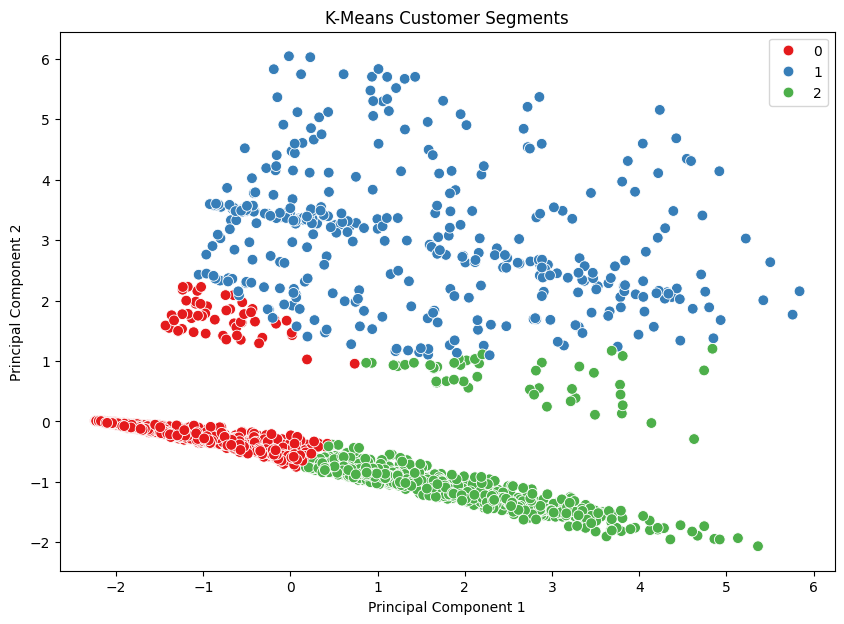

In [67]:
#K-Means Cluster Visualization
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="Set1",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Segments")

plt.show()

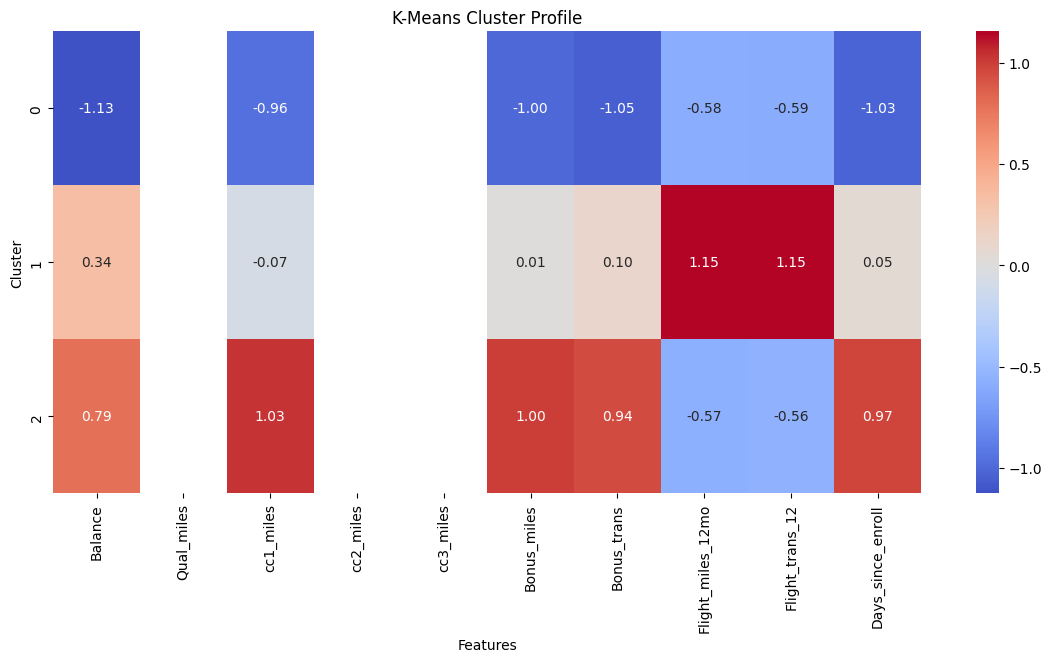

In [68]:
#Compare Cluster Profiles Using a Heatmap

cluster_profile = df_kmeans.groupby(
    "KMeans_Cluster"
)[features].mean()

cluster_profile_scaled = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("K-Means Cluster Profile")
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.show()

In [69]:
award_by_cluster = df_kmeans.groupby(
    "KMeans_Cluster"
)["Award?"].mean()

print(award_by_cluster.round(3))


KMeans_Cluster
0    0.165
1    0.434
2    0.437
Name: Award?, dtype: float64


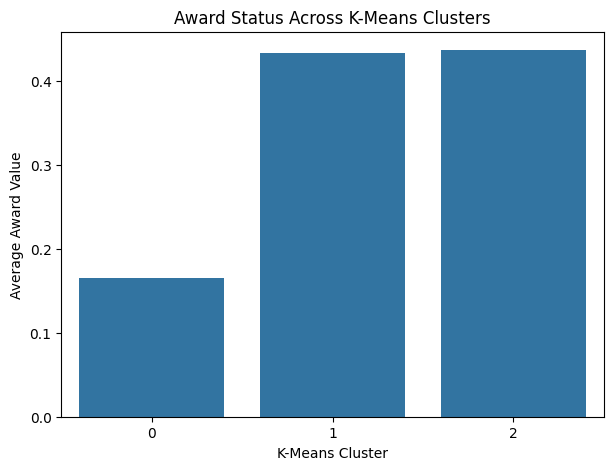

In [70]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=award_by_cluster.index,
    y=award_by_cluster.values
)

plt.xlabel("K-Means Cluster")
plt.ylabel("Average Award Value")
plt.title("Award Status Across K-Means Clusters")

plt.show()

In [71]:
#DBSCAN Cluster Analysis
DBSCAN(
    eps=1.5,
    min_samples=5
)

,eps,1.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [74]:
dbscan_final = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan_final.fit_predict(X_scaled)

df_dbscan = df_clean.copy()

df_dbscan["DBSCAN_Cluster"] = dbscan_labels

#counting the dbscan clusters
dbscan_counts = (
    df_dbscan["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

print(dbscan_counts)

DBSCAN_Cluster
-1      56
 0    2410
 1     335
 2      65
 3       9
Name: count, dtype: int64


In [75]:
#calculating the dbscan clusterings
dbscan_cluster_data = df_dbscan[
    df_dbscan["DBSCAN_Cluster"] != -1
]

dbscan_summary = dbscan_cluster_data.groupby(
    "DBSCAN_Cluster"
)[features].mean()

print(dbscan_summary.round(2))

                 Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
DBSCAN_Cluster                                                          
0               43875.28         0.0       1.79        1.0        1.0   
1               57898.87         0.0       2.07        1.0        1.0   
2               50796.54         0.0       1.09        1.0        1.0   
3               74393.00         0.0       3.44        1.0        1.0   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
DBSCAN_Cluster                                                                 
0                  10168.30         8.97               0.00              0.0   
1                  14506.07        10.81             326.13              1.0   
2                   3858.37         7.25             458.22              2.0   
3                  25792.67        15.89             600.00              2.0   

                Days_since_enroll  
DBSCAN_Cluster                     
0       

#### Interpretation of DBSCAN Clusters

DBSCAN Cluster 0 — Large moderate-activity group

    2,410 customers
    Average balance: 43,875
    Moderate bonus miles: 10,168
    Moderate bonus transactions: 9
    Very low recent flight activity.
    Insight

DBSCAN Cluster 1 — Moderate/high balance customers

    335 customers
    Average balance: 57,899
    Bonus miles: 14,506
    Bonus transactions: 10.8
    Recent flight miles: 326
    Recent flight transactions: 1

DBSCAN Cluster 2 — Frequent recent-flight customers

    65 customers
    Average balance: 50,797
    Bonus miles: 3,858
    Bonus transactions: 7.2
    Recent flight miles: 458
    Recent flight transactions: 2

DBSCAN Cluster 3 — Distinct high-value activity group

    Only 9 customers
    Highest balance among DBSCAN clusters: 74,393
    Highest cc1_miles: 3.4
    Highest bonus miles: 25,793
    High bonus transactions: 15.9
    Highest recent flight miles: 600

In [77]:
#Analyze DBSCAN Noise Points
noise_data = df_dbscan[
    df_dbscan["DBSCAN_Cluster"] == -1
]

print("Number of noise points:", len(noise_data))

print(noise_data[features].mean().round(2))

Number of noise points: 56
Balance              99267.88
Qual_miles               0.00
cc1_miles                2.91
cc2_miles                1.00
cc3_miles                1.00
Bonus_miles          25207.30
Bonus_trans             20.34
Flight_miles_12mo      351.46
Flight_trans_12          1.57
Days_since_enroll     4523.55
dtype: float64


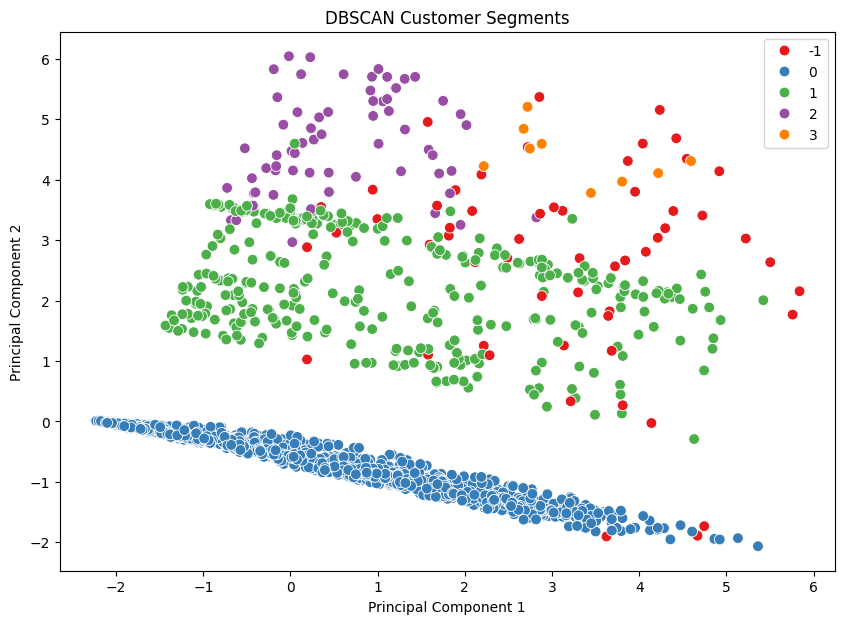

In [78]:
#Visualize DBSCAN Clusters
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=dbscan_labels,
    palette="Set1",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Segments")

plt.show()

In [79]:
#Compare K-Means and DBSCAN Cluster Structure
comparison_counts = pd.DataFrame({
    "K-Means": df_kmeans["KMeans_Cluster"].value_counts(),
    "DBSCAN": df_dbscan["DBSCAN_Cluster"].value_counts()
})

print(comparison_counts)

    K-Means  DBSCAN
-1      NaN      56
 0   1662.0    2410
 1    364.0     335
 2    849.0      65
 3      NaN       9


In [80]:
# K-Means Cluster 0:
# This is the largest cluster and represents customers with relatively
# low balances, low bonus miles, and low bonus transaction activity.

# K-Means Cluster 1:
# This cluster contains customers with moderate-to-high balances and
# bonus activity and the highest recent flight activity among K-Means clusters.

# K-Means Cluster 2:
# This cluster represents high-value and highly engaged loyalty customers
# with the highest balance, bonus miles, bonus transactions, and enrollment duration.

# DBSCAN Cluster 0:
# This is the largest density-based cluster, containing customers with
# moderate balances and bonus activity but limited recent flight activity.

# DBSCAN Cluster 1:
# This group contains customers with relatively high balances and bonus
# activity along with moderate recent flight activity.

# DBSCAN Cluster 2:
# This is a small group characterized by relatively high recent flight
# activity and comparatively lower bonus accumulation.

# DBSCAN Cluster 3:
# This very small group contains customers with high balances, high bonus
# miles, high credit-card mileage, and relatively high recent flight activity.

# DBSCAN Noise (-1):
# These customers do not belong to a sufficiently dense group according
# to the selected DBSCAN parameters and may represent unusual behavior.

# Visualization of Clustering Results

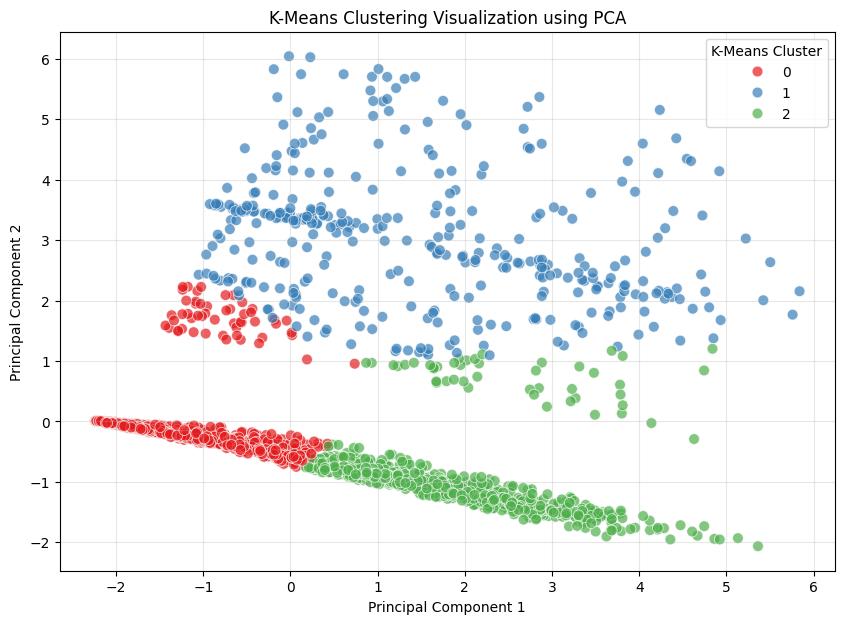

In [81]:
# ============================================
#Visualization - K-Means Clusters
# ============================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="Set1",
    s=60,
    alpha=0.7
)

plt.title("K-Means Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="K-Means Cluster")
plt.grid(True, alpha=0.3)
plt.show()

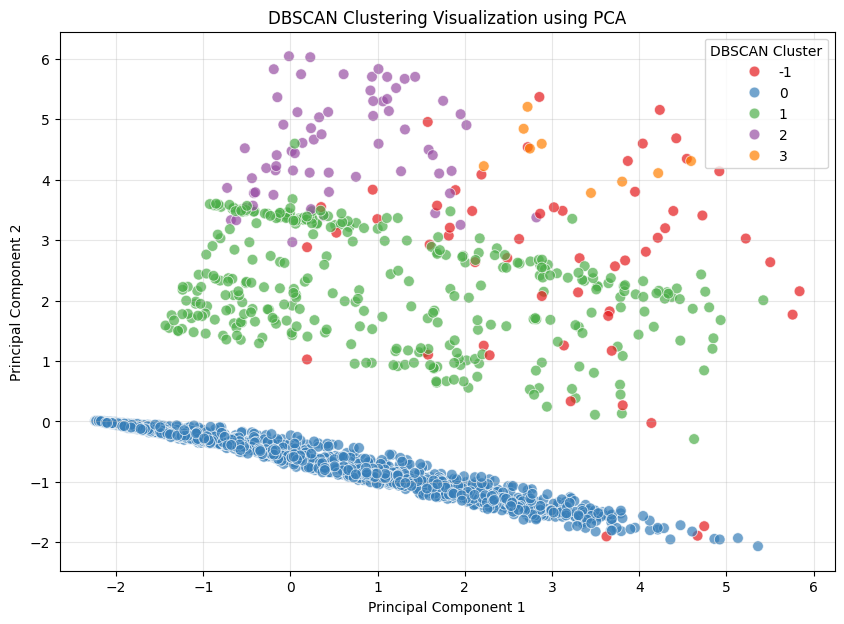

In [82]:
# ============================================
# DBSCAN Clustering Visualization
# ============================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=dbscan_labels,
    palette="Set1",
    s=60,
    alpha=0.7
)

plt.title("DBSCAN Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster")
plt.grid(True, alpha=0.3)
plt.show()

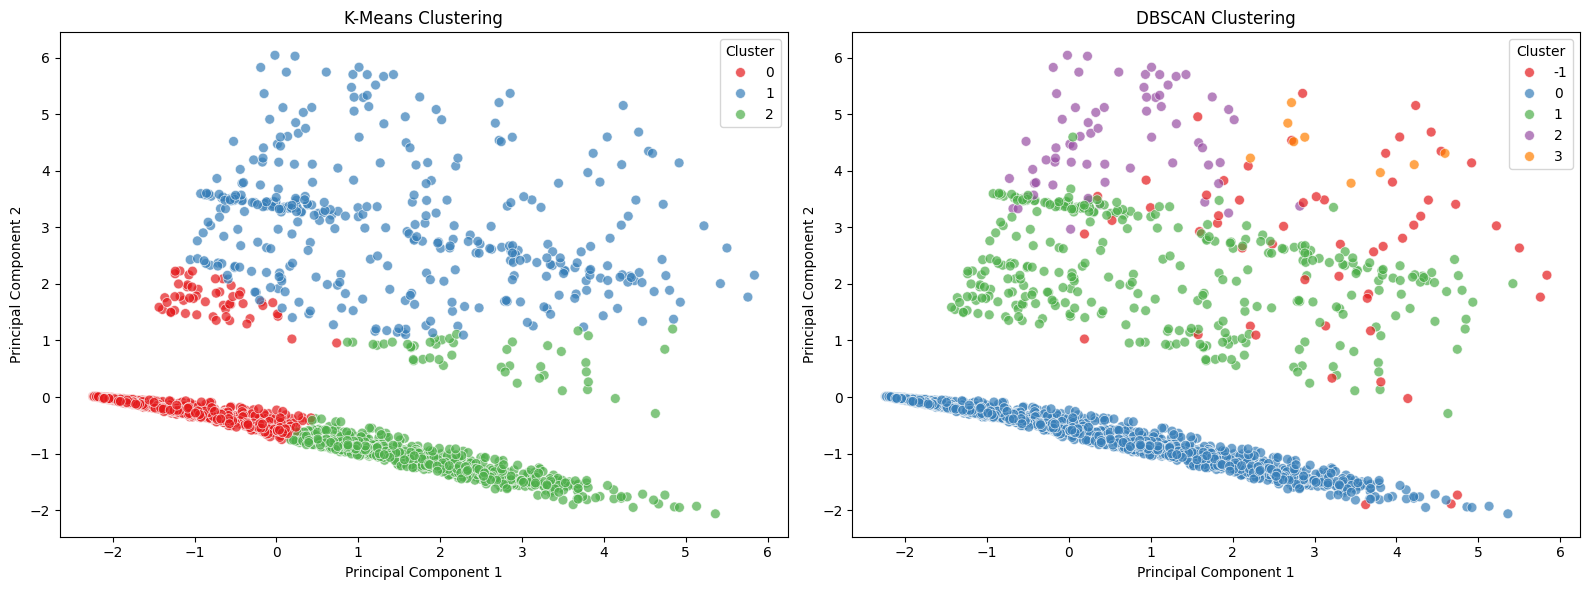

In [84]:
# ============================================
# Compare K-Means and DBSCAN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="Set1",
    s=50,
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend(title="Cluster")

# DBSCAN
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=dbscan_labels,
    palette="Set1",
    s=50,
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title("DBSCAN Clustering")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

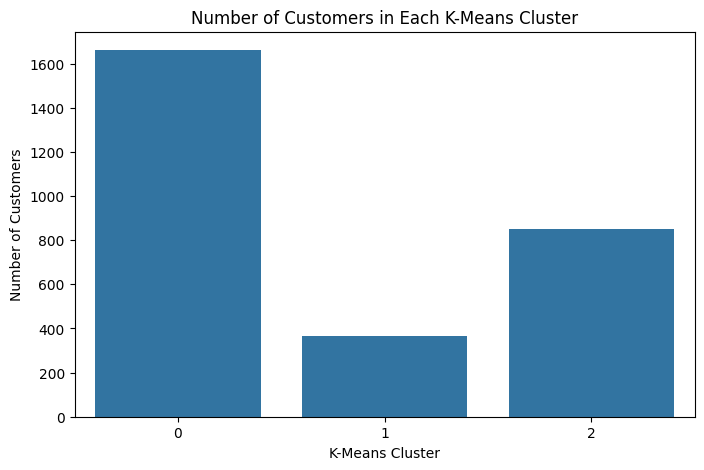

In [85]:
# K-Means cluster sizes

kmeans_counts = pd.Series(kmeans_labels).value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=kmeans_counts.index,
    y=kmeans_counts.values
)

plt.title("Number of Customers in Each K-Means Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("Number of Customers")

plt.show()

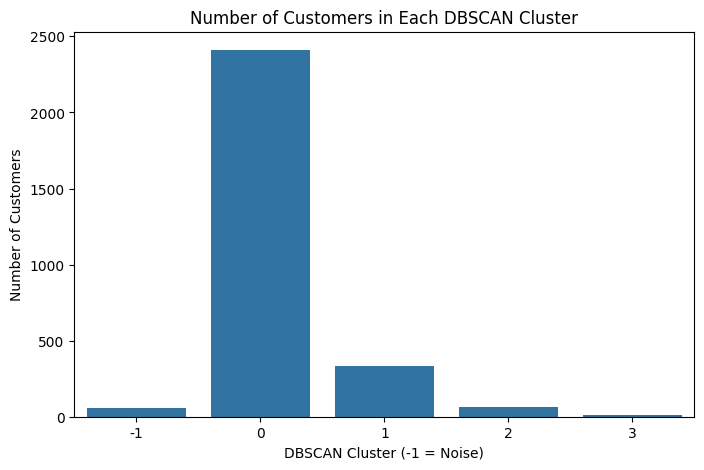

In [86]:
# DBSCAN cluster sizes

dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=dbscan_counts.index.astype(str),
    y=dbscan_counts.values
)

plt.title("Number of Customers in Each DBSCAN Cluster")
plt.xlabel("DBSCAN Cluster (-1 = Noise)")
plt.ylabel("Number of Customers")

plt.show()

# Evaluation and Performance Metrics:

In [87]:
# ============================================
# Evaluation - K-Means
# ============================================

from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))

K-Means Silhouette Score: 0.3776


In [88]:
# ============================================
# DBSCAN Silhouette Score
# ============================================

# Identify non-noise observations
non_noise = dbscan_labels != -1

# Extract non-noise labels
dbscan_non_noise_labels = dbscan_labels[non_noise]

# Calculate silhouette score
dbscan_silhouette = silhouette_score(
    X_scaled[non_noise],
    dbscan_non_noise_labels
)

print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 4))

DBSCAN Silhouette Score: 0.3233


In [89]:
# ============================================
# Compare Clustering Performance
# ============================================

comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Number_of_Clusters": [3, 4],
    "Noise_Points": [0, 56],
    "Silhouette_Score": [
        kmeans_silhouette,
        dbscan_silhouette
    ]
})

print(comparison)

  Algorithm  Number_of_Clusters  Noise_Points  Silhouette_Score
0   K-Means                   3             0          0.377579
1    DBSCAN                   4            56          0.323308


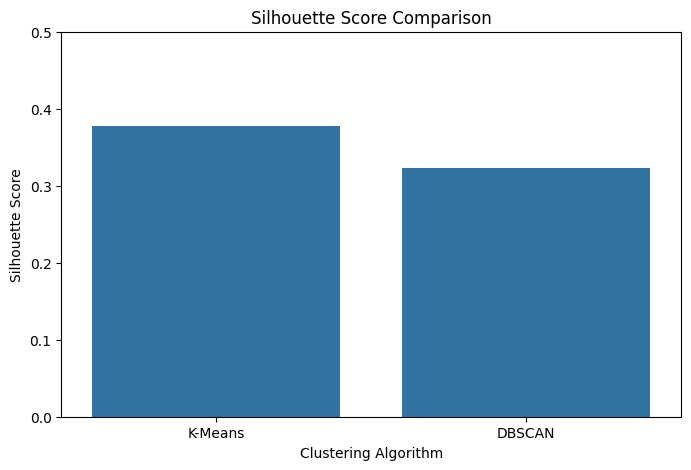

In [90]:
# ============================================
# Silhouette Score Comparison Plot
# ============================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Silhouette_Score"
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.ylim(0, 0.5)

plt.show()

In [91]:
# ============================================
# Silhouette Score for Different K Values
# ============================================

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

# Display results
kmeans_evaluation = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette_Score": silhouette_scores
})

print(kmeans_evaluation)

    K  Silhouette_Score
0   2          0.349070
1   3          0.377579
2   4          0.271655
3   5          0.278902
4   6          0.270602
5   7          0.285051
6   8          0.282150
7   9          0.280880
8  10          0.283679


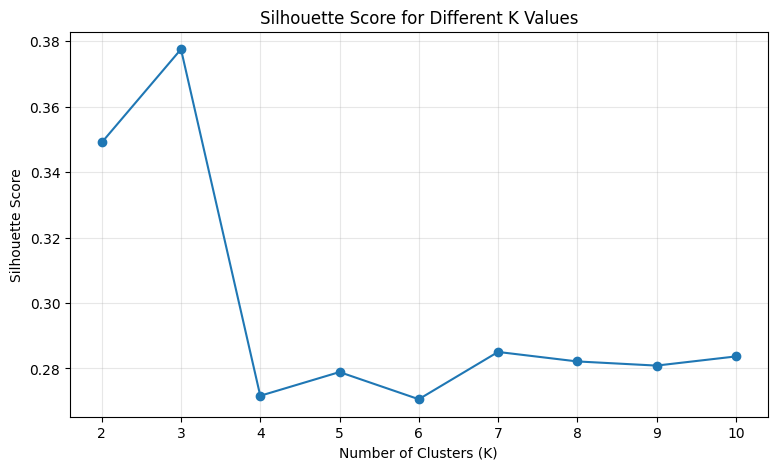

In [92]:
# Plot Silhouette Score for different K values

plt.figure(figsize=(9, 5))

plt.plot(
    kmeans_evaluation["K"],
    kmeans_evaluation["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.show()

In [93]:
#for our selected dbscan model
DBSCAN(
    eps=1.5,
    min_samples=5
)

,eps,1.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [94]:
#Final evaluation values

#K-Means
#    Number of clusters = 3
#    Noise points        = 0
#   Silhouette Score    = 0.3776

#DBSCan
#    Number of clusters = 4
#    Noise points        = 56
#   Silhouette Score    = 0.3233